## LIGO Voyager Noise Budgets
Plots adapted from: https://dcc.ligo.org/public/0148/P1800001/002/Schreiber%20thesis%20e-print.pdf

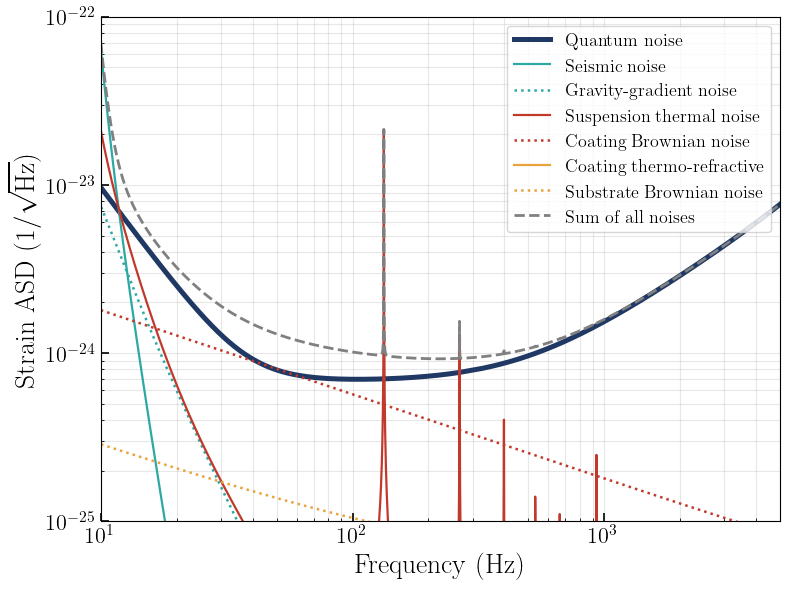

Saved: /Users/asca/PhD/photodiodes/code/gwinc/fig/gwinc_noise_budget_Voyager.png


In [2]:
import os
import gwinc
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
path = "/Users/asca/PhD/photodiodes/code/gwinc/"
fig_dir = os.path.join(path, "fig")
os.makedirs(fig_dir, exist_ok=True)
# Voyager = 1550 nm cryogenic next-gen design 
budget = gwinc.load_budget('Voyager')
trace = budget.run()
freq = trace.freq
noise_style = {
    'Quantum':            dict(label=r'Quantum noise',            color='#1f3864', ls='-', lw=3.6),
    'Seismic':            dict(label=r'Seismic noise',             color='#2ca9a3', ls='-', lw=1.6),
    'Newtonian':          dict(label=r'Gravity-gradient noise',    color='#2ca9a3', ls=':', lw=1.8),
    'SuspensionThermal':  dict(label=r'Suspension thermal noise',  color='#c0392b', ls='-', lw=1.6),
    'CoatingBrownian':    dict(label=r'Coating Brownian noise',    color='#c0392b', ls=':', lw=1.8),
    'CoatingThermoOptic': dict(label=r'Coating thermo-refractive', color='#e8a33d', ls='-', lw=1.6),
    'SubstrateBrownian':  dict(label=r'Substrate Brownian noise',  color='#e8a33d', ls=':', lw=1.8),
}

fig, ax = plt.subplots(figsize=(8, 6))
available_keys = list(trace.keys())
for key, style in noise_style.items():
    if key in available_keys:
        sub = trace[key]
        ax.loglog(freq, sub.asd, label=style['label'], color=style['color'], linestyle=style['ls'], linewidth=style['lw'])
ax.loglog(freq, trace.asd, label=r'Sum of all noises', color='gray', linestyle='--', linewidth=2)
ax.set_xlabel(r'Frequency (Hz)', fontsize=20)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=20)
ax.set_xlim(10, 5000)
ax.set_ylim(1e-25, 1e-22)
ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2, direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper right', fontsize=13, frameon=True)
fig.tight_layout()
save_path = os.path.join(fig_dir, "gwinc_noise_budget_Voyager.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved: {save_path}")

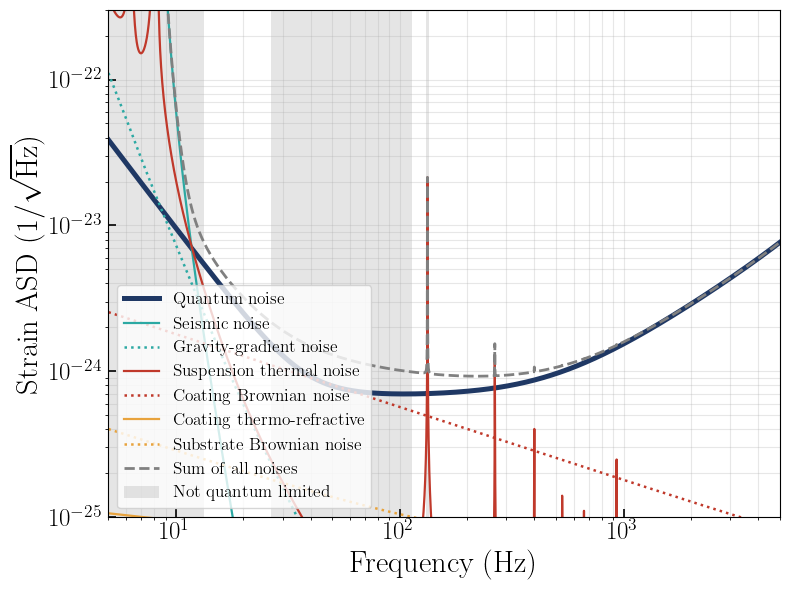

    5.0 -    13.3 Hz : Seismic
   26.7 -   113.3 Hz : CoatingBrownian
  130.9 -   135.0 Hz : SuspensionThermal


In [3]:
import numpy as np
from matplotlib.patches import Patch

def classical_bands(trace, thresh=0.5, min_ratio=1.03):
    """Frequency bands where quantum noise contributes less than `thresh`
    of the total noise POWER, i.e. where Voyager is not quantum limited.
    min_ratio drops slivers (violin modes) narrower than that factor in f."""
    f = trace.freq
    mask = trace['Quantum'].asd**2 < thresh * trace.asd**2
    idx = np.where(mask)[0]
    if not len(idx):
        return []
    segs = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    return [(f[s[0]], f[s[-1]]) for s in segs if f[s[-1]] / f[s[0]] >= min_ratio]

def dominant(trace, lo, hi):
    """Which classical noise wins in a band (median PSD over the band)."""
    sel = (trace.freq >= lo) & (trace.freq <= hi)
    return max((np.median(trace[k].asd[sel]**2), k)
               for k in trace.keys() if k != 'Quantum')[1]

fig, ax = plt.subplots(figsize=(8, 6))

# --- gray shading, drawn first so it sits under the curves ---
bands = classical_bands(trace)
for lo, hi in bands:
    ax.axvspan(lo, hi, color='0.55', alpha=0.22, lw=0, zorder=0)

for key, style in noise_style.items():
    if key in trace.keys():
        ax.loglog(freq, trace[key].asd, label=style['label'],
                  color=style['color'], linestyle=style['ls'], linewidth=style['lw'])
ax.loglog(freq, trace.asd, label=r'Sum of all noises', color='gray', ls='--', lw=2)

handles, labels = ax.get_legend_handles_labels()
handles.append(Patch(facecolor='0.55', alpha=0.22))
labels.append(r'Not quantum limited')
#ax.legend(handles, labels, loc='lower left', fontsize=10.5, frameon=True)
ax.legend(handles, labels, loc='lower left', fontsize=12.5, frameon=True)
ax.set_xlabel(r'Frequency (Hz)', fontsize=22)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=22)
ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.2, direction='in')

#ax.set_xlabel(r'Frequency (Hz)', fontsize=20)
#ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=20)
ax.set_xlim(5, 5000)
ax.set_ylim(1e-25, 3e-22)
#ax.tick_params(axis='both', which='major', labelsize=16, length=6, width=1.2, direction='in')
#ax.tick_params(axis='both', which='minor', direction='in')
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()
fig.savefig(os.path.join(fig_dir, "gwinc_noise_budget_Voyager_shaded.png"),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

for lo, hi in bands:
    print(f"{lo:7.1f} - {hi:7.1f} Hz : {dominant(trace, lo, hi)}")

Substrate thermo elastic and residual gas were missing. Voyager also has ITMThermoRefractive noise in the silicon test mass substrate (due to 2micron light transmitted through silicon ITMs).

130-135 Hz band is the first violin mode (raise min ratio to 1.1 remove it)

keys     : ['Quantum', 'Seismic', 'Newtonian', 'SuspensionThermal', 'CoatingBrownian', 'CoatingThermoOptic', 'ITMThermoRefractive', 'SubstrateBrownian', 'SubstrateThermoElastic', 'ResidualGas']
unstyled : none
closure  : max|sum/total-1| = 6.7e-16
    5.0 -    13.3 Hz | Seismic 99%,  SuspensionThermal 1%,  Newtonian 0%,  Quantum 0%,  ITMThermoRefractive 0%
   26.7 -   113.3 Hz | CoatingBrownian 38%,  Quantum 38%,  ITMThermoRefractive 13%,  ResidualGas 10%,  SubstrateBrownian 1%
  130.9 -   135.0 Hz | Quantum 42%,  SuspensionThermal 21%,  CoatingBrownian 21%,  ResidualGas 12%,  ITMThermoRefractive 3%


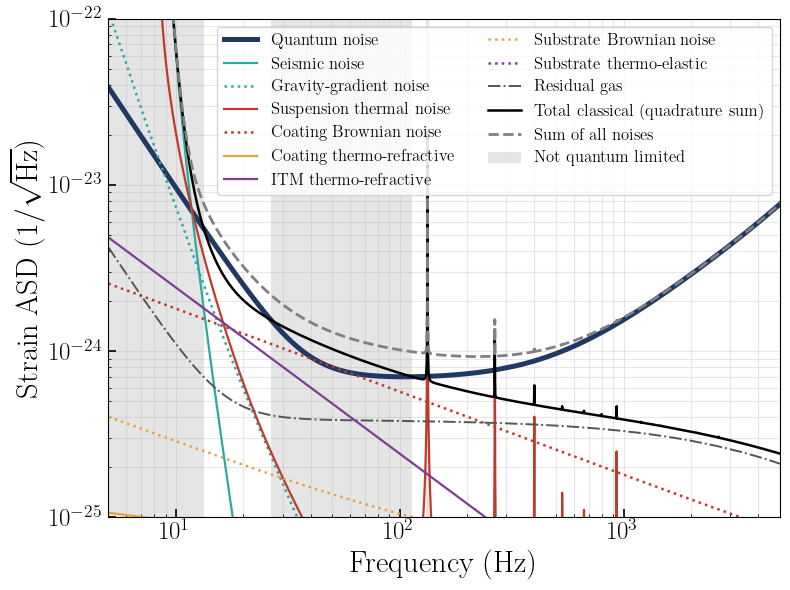

In [ ]:
import numpy as np
from matplotlib.patches import Patch

# extend your style dict; extras get a visible fallback rather than being dropped
noise_style_ext = dict(noise_style)
noise_style_ext.update({
    'ITMThermoRefractive':     dict(label=r'ITM thermo-refractive',     color='#7d3c98', ls='-',  lw=1.6),
    'SubstrateThermoElastic':  dict(label=r'Substrate thermo-elastic',  color='#7d3c98', ls=':',  lw=1.8),
    'ResidualGas':             dict(label=r'Residual gas',              color='#555555', ls='-.', lw=1.4),
    'ExcessGas':               dict(label=r'Residual gas',              color='#555555', ls='-.', lw=1.4),
})
QK = 'Quantum' if 'Quantum' in trace.keys() else 'QuantumVacuum'

def audit(trace, qkey=QK):
    keys = list(trace.keys())
    unstyled = [k for k in keys if k not in noise_style_ext]
    closure = np.max(np.abs(sum(trace[k].asd**2 for k in keys) / trace.asd**2 - 1))
    print('keys     :', keys)
    print('unstyled :', unstyled or 'none')
    print('closure  : max|sum/total-1| = %.1e' % closure)
    return keys

def classical_bands(trace, qkey=QK, thresh=0.5, min_ratio=1.03):
    f = trace.freq
    idx = np.where(trace[qkey].asd**2 < thresh * trace.asd**2)[0]
    if not len(idx):
        return []
    segs = np.split(idx, np.where(np.diff(idx) > 1)[0] + 1)
    return [(f[s[0]], f[s[-1]]) for s in segs if f[s[-1]] / f[s[0]] >= min_ratio]

def breakdown(trace, bands, qkey=QK, top=5):
    for lo, hi in bands:
        sel = (trace.freq >= lo) & (trace.freq <= hi)
        tot = np.median(trace.asd[sel]**2)
        c = sorted(((np.median(trace[k].asd[sel]**2) / tot, k) for k in trace.keys()), reverse=True)
        print(f'{lo:7.1f} - {hi:7.1f} Hz | ' + ',  '.join(f'{k} {100*v:.0f}%' for v, k in c[:top]))

def plot_shaded(trace, qkey=QK, fname=None):
    f = trace.freq
    fig, ax = plt.subplots(figsize=(8, 6))
    bands = classical_bands(trace, qkey)
    for lo, hi in bands:
        ax.axvspan(lo, hi, color='0.55', alpha=0.22, lw=0, zorder=0)
    for k in trace.keys():                      # every term, not a whitelist
        s = noise_style_ext.get(k, dict(label=k.replace('_', ' '), color='k', ls='-', lw=1.0))
        ax.loglog(f, trace[k].asd, label=s['label'], color=s['color'], ls=s['ls'], lw=s['lw'])
    classical = np.sqrt(sum(trace[k].asd**2 for k in trace.keys() if k != qkey))
    ax.loglog(f, classical, color='k', lw=1.8, label=r'Total classical (quadrature sum)')
    ax.loglog(f, trace.asd, color='gray', ls='--', lw=2, label=r'Sum of all noises')
    h, l = ax.get_legend_handles_labels()
    h.append(Patch(facecolor='0.55', alpha=0.22)); l.append(r'Not quantum limited')
    ax.legend(h, l, loc='upper right', fontsize=12, frameon=True, ncol=2)
    ax.set_xlabel(r'Frequency (Hz)', fontsize=22)
    ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=22)
    ax.set_xlim(5, 5000); ax.set_ylim(1e-25, 1e-22)
    ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.2, direction='in')
    ax.tick_params(axis='both', which='minor', direction='in')
    ax.grid(True, which='both', alpha=0.3)
    fig.tight_layout()
    if fname:
        fig.savefig(os.path.join(fig_dir, fname), dpi=300, bbox_inches='tight', facecolor='white')
    return fig, bands

audit(trace)
fig, bands = plot_shaded(trace, fname='gwinc_noise_budget_Voyager_shaded_explicit.png')
breakdown(trace, bands)
plt.show()

### Phase, amplitude and FD squeezing

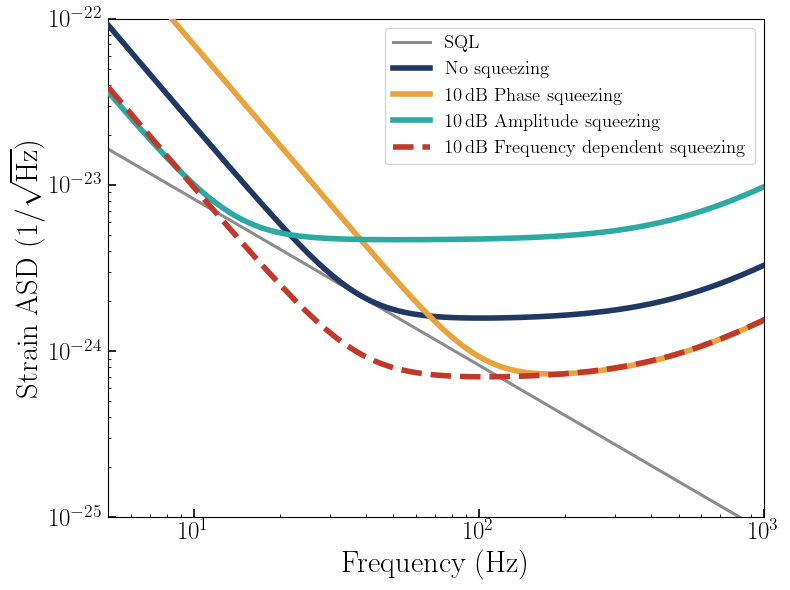

Saved: /Users/asca/PhD/photodiodes/code/gwinc/fig/SQL_freq_dependent_squeezing_Voyager.png


In [5]:
import os
import numpy as np
import gwinc
from gwinc import const
import matplotlib.pyplot as plt
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
path = "/Users/asca/PhD/photodiodes/code/gwinc/"
fig_dir = os.path.join(path, "fig")
os.makedirs(fig_dir, exist_ok=True)
freq = np.logspace(np.log10(5), np.log10(3000), 1000)
base_ifo_name = 'Voyager'
def get_trace(sqz_type, amp_db, sqz_angle, qe=None, base=base_ifo_name):
    '''Loads Voyager's own ifo.yaml Squeezer block (filter cavity, injection
    loss, etc. all come straight from the yaml) and provides option to override the
    following parameters: squeezing type/level/angle, and optionally QE.'''
    budget = gwinc.load_budget(base, freq=freq)
    ifo = budget.ifo
    ifo.Squeezer.Type = sqz_type
    ifo.Squeezer.AmplitudedB = amp_db
    ifo.Squeezer.SQZAngle = sqz_angle
    if qe is not None:
        ifo.Optics.PhotoDetectorEfficiency = qe
    return budget, budget.run(ifo=ifo)

b_none,  t_none  = get_trace('Freq Independent', 1e-6, 0)          # no squeezing
b_amp,   t_amp   = get_trace('Freq Independent', 10,    np.pi / 2)  # 6 dB amplitude sqz.
b_phase, t_phase = get_trace('Freq Independent', 10,    0)          # 6 dB phase sqz.
b_fd,    t_fd    = get_trace('Freq Dependent',   10,    0)          # 6 dB freq-dep. sqz.


# SQL is purely kinematic (mass, arm length) -- QE-independent
b0, _ = get_trace('Freq Independent', 1e-6, 0) # get_trace hads back a tuple of (budget, budger.run(ifo=ifo)) we only need one
m = b0.ifo.Suspension.Stage[0].Mass
L = b0.ifo.Infrastructure.Length # b_none can be used here
Omega = 2 * np.pi * freq
h_SQL = np.sqrt(8 * const.hbar / (m * (Omega * L) ** 2))
_, t_nosqz = get_trace('Freq Independent', 1e-6, 0)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(freq, h_SQL,   color='0.55',    ls='-',  lw=2.2, zorder=2, label=r'SQL')
ax.loglog(freq, t_none['Quantum'].asd,  color='#1f3864', ls='-',  lw=4.0, zorder=3, label=r'No squeezing')
ax.loglog(freq, t_phase['Quantum'].asd, color='#e8a33d', ls='-',  lw=4.0, zorder=4, label=r'10\,dB Phase squeezing')
ax.loglog(freq, t_amp['Quantum'].asd,   color='#2ca9a3', ls='-',  lw=4.0, zorder=5, label=r'10\,dB Amplitude squeezing')
ax.loglog(freq, t_fd['Quantum'].asd,    color='#c0392b', ls='--', lw=4.0, zorder=6, label=r'10\,dB Frequency dependent squeezing')

ax.set_xlabel(r'Frequency (Hz)', fontsize=22)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=22)
ax.set_xlim(5, 1000)
ax.set_ylim(1e-25, 1e-22)
ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.2, direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
ax.legend(loc='upper right', fontsize=13.5, frameon=True)
fig.tight_layout()
save_path = os.path.join(fig_dir, "SQL_freq_dependent_squeezing_Voyager.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {save_path}")

Even with perfect quantum noise reduction, aLIGO is heavily limited at low frequencies by non-quantum noises, such as suspension thermal noise, coating thermal noise, and seismic noise. These noises form a "floor" that often sits above or right at the SQL. If these classical noises are high, reducing the quantum noise below the SQL becomes invisible in the total strain sensitivity.
Voyager: Voyager is a proposed upgrade designed specifically to be much quieter at these critical frequencies. It assumes improved coatings (reducing thermal noise) and other upgrades that lower the "classical" noise floor. Because the non-quantum noise is lower, the SQL becomes the dominant barrier, and therefore, overcoming it provides a clearly visible improvement in the total sensitivity curve.

Optomechanics: Voyager: The Voyager model in gwinc is designed with significantly higher circulating laser power than aLIGO. This higher power shifts the shot noise floor down and the radiation pressure noise up, changing the frequency at which they intersect (the crossover frequency).

OBS: Voyager paper contains squeezing parameters to compare against.

### Impact of PD QE improvement scenarios on achievable squeezing levels

SPS Poster version

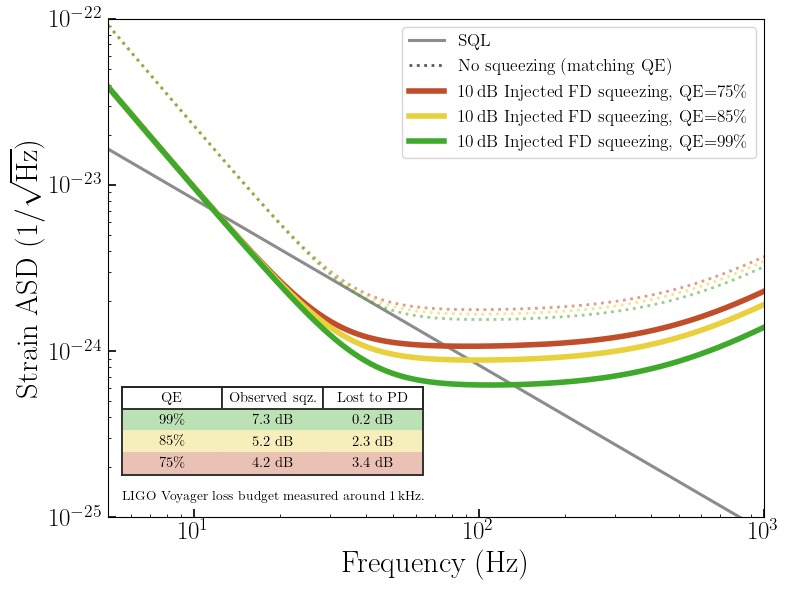

Saved: /Users/asca/PhD/photodiodes/code/gwinc/fig/qe_vs_freq_dependent_squeezing.png


In [ ]:
import os
import numpy as np
import gwinc
from gwinc import const
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
path = "/Users/asca/PhD/photodiodes/code/gwinc/"
fig_dir = os.path.join(path, "fig")
os.makedirs(fig_dir, exist_ok=True)

freq = np.logspace(np.log10(5), np.log10(3000), 1000)
base_ifo_name = 'Voyager'

def get_trace(sqz_type, amp_db, sqz_angle, qe=None, base=base_ifo_name):
    '''Loads Voyager's own ifo.yaml Squeezer block (filter cavity, injection
    loss, etc. all come straight from the yaml) and provides option to override the
    following parameters: squeezing type/level/angle, and optionally QE.'''
    budget = gwinc.load_budget(base, freq=freq)
    ifo = budget.ifo
    ifo.Squeezer.Type = sqz_type
    ifo.Squeezer.AmplitudedB = amp_db
    ifo.Squeezer.SQZAngle = sqz_angle
    if qe is not None:
        ifo.Optics.PhotoDetectorEfficiency = qe
    return budget, budget.run(ifo=ifo)

# SQL is purely kinematic (mass, arm length); QE-independent
b0, _ = get_trace('Freq Independent', 1e-6, 0)
m = b0.ifo.Suspension.Stage[0].Mass
L = b0.ifo.Infrastructure.Length
Omega = 2 * np.pi * freq
h_SQL = np.sqrt(8 * const.hbar / (m * (Omega * L) ** 2))

QE_style = [
    (0.75, "#c04e2b"),  # red
    (0.85, "#e8d13d"),  # yellow
    (0.99, "#3fa92c"),  # green
]

BAND = (800, 1000) # shot-noise-limited band where squeezing is read off

def sqz_db(asd_ref, asd_sqz):
    k = (freq > BAND[0]) & (freq < BAND[1])
    return np.median(-20 * np.log10(asd_sqz[k] / asd_ref[k]))

def tint(c, f=0.35):
    """Light version of a curve colour: blend it f-of-the-way from white."""
    r, g, b = to_rgb(c)
    return (1 - f + f*r, 1 - f + f*g, 1 - f + f*b)

# reference with a perfect photodiode: isolates what the PD costs
_, r1 = get_trace('Freq Independent', 1e-6, 0, qe=1.0)
_, f1 = get_trace('Freq Dependent',  10,   0, qe=1.0)
base = sqz_db(r1['Quantum'].asd, f1['Quantum'].asd)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(freq, h_SQL, color='0.55', ls='-', lw=2.2, label=r'SQL')

rows, cols = [], []
for qe, c in QE_style:
    _, t_no = get_trace('Freq Independent', 1e-6, 0, qe=qe)
    _, t_sq = get_trace('Freq Dependent',  10,   0, qe=qe)
    ax.loglog(freq, t_no['Quantum'].asd, color=c, ls=':', lw=2.0, alpha=0.55)
    ax.loglog(freq, t_sq['Quantum'].asd, color=c, ls='-', lw=4.0,
              label=r'10\,dB Injected FD squeezing, QE=' + f'{qe*100:.0f}' + r'\%')
    obs = sqz_db(t_no['Quantum'].asd, t_sq['Quantum'].asd)
    rows.append([f'{qe*100:.0f}' + r'\%', f'{obs:.1f} dB', f'{base - obs:.1f} dB'])
    cols.append(c)
rows, cols = rows[::-1], cols[::-1]        # highest QE at the top

handles, labels = ax.get_legend_handles_labels()
handles.insert(1, Line2D([], [], color='0.35', ls=':', lw=2.0))
labels.insert(1, r'No squeezing (matching QE)')
ax.legend(handles, labels, loc='upper right', fontsize=12.5, frameon=True)

BBOX = [0.02, 0.085, 0.46, 0.175]
tbl = ax.table(cellText=rows,
               colLabels=[r'QE', r'Observed sqz.', r'Lost to PD'],
               cellLoc='center', loc='lower left', bbox=BBOX)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
for (i, j), cell in tbl.get_celld().items():
    cell.set_linewidth(1.3)
    if i == 0:                                   # header: dark outline
        cell.set_facecolor('white')
        cell.set_edgecolor('0.15')
    else:                                        # data: edge hidden in the fill
        fc = tint(cols[i - 1])
        cell.set_facecolor(fc)
        cell.set_edgecolor(fc)

x0, y0, w, h = BBOX                               # outer perimeter
ax.plot([x0, x0 + w, x0 + w, x0, x0], [y0, y0, y0 + h, y0 + h, y0],
        transform=ax.transAxes, color='0.15', lw=1.3,
        solid_joinstyle='miter', clip_on=False, zorder=5)
ax.plot([x0, x0 + w], [y0 + h * len(rows) / (len(rows) + 1)] * 2, transform=ax.transAxes,
        color='0.15', lw=1.3, clip_on=False, zorder=5)

ax.text(0.02, 0.033, r'LIGO Voyager loss budget measured around 1\,kHz.',
        transform=ax.transAxes, fontsize=9.5)

ax.set_xlabel(r'Frequency (Hz)', fontsize=22)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=22)
ax.set_xlim(5, 1000)
ax.set_ylim(1e-25, 1e-22)
ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.2, direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
fig.tight_layout()
save_path = os.path.join(fig_dir, "qe_vs_freq_dependent_squeezing_Voyager_SPS.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#fig.savefig(os.path.join(fig_dir, "PD_qe_vs_freq_dependent_squeezing_Voyager_poster.svg"), bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {save_path}")

### Adding a a perfect photodiode row

yaml default PhotoDetectorEfficiency = 0.95
yaml Squeezer: Freq Independent, 1e-06 dB, InjectionLoss = 0.05


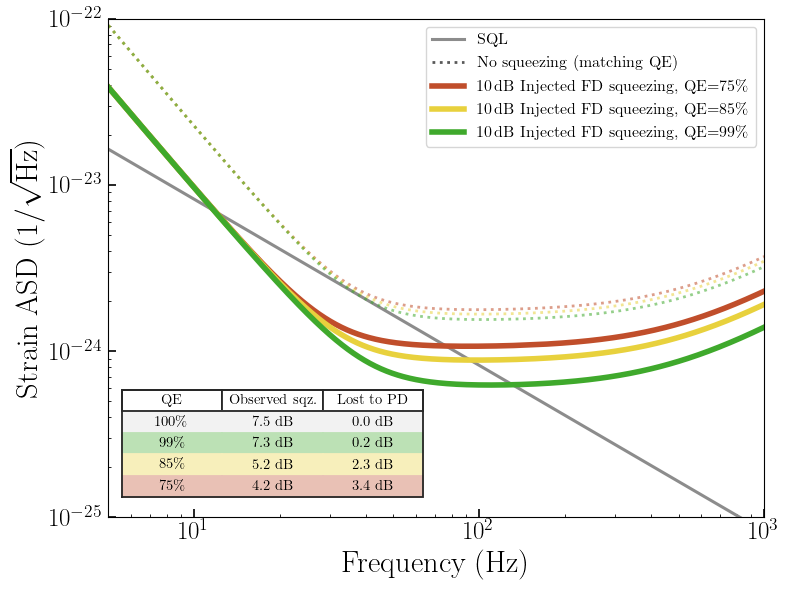

Saved: /Users/asca/PhD/photodiodes/code/gwinc/fig/qe_vs_fd_squeezing_10dB.png


In [ ]:
import os
import numpy as np
import gwinc
from gwinc import const
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.colors import to_rgb

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{amsmath}",
})
path = "/Users/asca/PhD/photodiodes/code/gwinc/"
fig_dir = os.path.join(path, "fig")
os.makedirs(fig_dir, exist_ok=True)

freq = np.logspace(np.log10(5), np.log10(3000), 1000)
base_ifo_name = 'Voyager'

# ---------------------------------------------------------------------------
#  KNOBS
# ---------------------------------------------------------------------------
INJ_DB = 10.0      # injected squeezing [dB].  Marcelle's question: try 15, 20.
BAND   = (800, 1000)

#  (QE, colour, label-suffix).  QE = 1.0 is the ceiling: what the rest of the
#  chain would give with a perfect photodiode.  It was already being computed
#  to fill the "Lost to PD" column -- now it is drawn, so the gap between the
#  ceiling and each coloured curve IS the dB lost to the diode.
QE_IDEAL = 1.00
QE_STYLE = [
    (0.75, "#c04e2b", None),   # red    -- HgCdTe / eInGaAs today
    (0.85, "#e8d13d", None),   # yellow
    (0.99, "#3fa92c", None),   # green  -- lattice-matched InGaAs @1064
    # (0.995, "#1f7a12", 'IGHQEX typ.'),   # uncomment for the best real device
    # (0.9xx, "#1f3864", 'measured'),      # <-- drop the alog/bench number here
]

# ---------------------------------------------------------------------------


def get_trace(sqz_type, amp_db, sqz_angle, qe=None, base=base_ifo_name):
    '''Loads Voyager's own ifo.yaml Squeezer block (filter cavity, injection
    loss, etc. all come straight from the yaml) and provides option to override
    the following parameters: squeezing type/level/angle, and optionally QE.'''
    budget = gwinc.load_budget(base, freq=freq)
    ifo = budget.ifo
    ifo.Squeezer.Type = sqz_type
    ifo.Squeezer.AmplitudedB = amp_db
    ifo.Squeezer.SQZAngle = sqz_angle
    if qe is not None:
        ifo.Optics.PhotoDetectorEfficiency = qe
    return budget, budget.run(ifo=ifo)


# SQL is purely kinematic (mass, arm length); QE-independent
b0, _ = get_trace('Freq Independent', 1e-6, 0)
m = b0.ifo.Suspension.Stage[0].Mass
L = b0.ifo.Infrastructure.Length
Omega = 2 * np.pi * freq
h_SQL = np.sqrt(8 * const.hbar / (m * (Omega * L) ** 2))

print(f"yaml default PhotoDetectorEfficiency = {b0.ifo.Optics.PhotoDetectorEfficiency}")
print(f"yaml Squeezer: {b0.ifo.Squeezer.Type}, {b0.ifo.Squeezer.AmplitudedB} dB, "
      f"InjectionLoss = {b0.ifo.Squeezer.InjectionLoss}")


def sqz_db(asd_ref, asd_sqz):
    k = (freq > BAND[0]) & (freq < BAND[1])
    return np.median(-20 * np.log10(asd_sqz[k] / asd_ref[k]))


def tint(c, f=0.35):
    """Light version of a curve colour: blend it f-of-the-way from white."""
    r, g, b = to_rgb(c)
    return (1 - f + f * r, 1 - f + f * g, 1 - f + f * b)


# --- the ceiling: a perfect photodiode, everything else unchanged ------------
_, r1 = get_trace('Freq Independent', 1e-6,   0, qe=QE_IDEAL)
_, f1 = get_trace('Freq Dependent',   INJ_DB, 0, qe=QE_IDEAL)
base = sqz_db(r1['Quantum'].asd, f1['Quantum'].asd)

fig, ax = plt.subplots(figsize=(8, 6))
ax.loglog(freq, h_SQL, color='0.55', ls='-', lw=2.2, label=r'SQL')

# --- the ceiling curve, drawn thin so it reads as a bound, not a case -------
#ax.loglog(freq, f1['Quantum'].asd, color='0.15', ls=(0, (6, 2)), lw=1.8, zorder=6,label=r'Perfect PD (QE$\,=\,$100\,\%): ceiling')

rows, cols = [], []
for entry in QE_STYLE:
    qe, c = entry[0], entry[1]
    suffix = entry[2] if len(entry) > 2 else None
    _, t_no = get_trace('Freq Independent', 1e-6,   0, qe=qe)
    _, t_sq = get_trace('Freq Dependent',   INJ_DB, 0, qe=qe)
    ax.loglog(freq, t_no['Quantum'].asd, color=c, ls=':', lw=2.0, alpha=0.55)
    lab = (rf'{INJ_DB:.0f}' + r'\,dB Injected FD squeezing, QE='
           + f'{qe*100:.1f}'.rstrip('0').rstrip('.') + r'\%')
    if suffix:
        lab += rf' ({suffix})'
    ax.loglog(freq, t_sq['Quantum'].asd, color=c, ls='-', lw=4.0, label=lab)
    obs = sqz_db(t_no['Quantum'].asd, t_sq['Quantum'].asd)
    name = f'{qe*100:.1f}'.rstrip('0').rstrip('.') + r'\%'
    rows.append([name, f'{obs:.1f} dB', f'{base - obs:.1f} dB'])
    cols.append(c)

# ceiling row at the top of the table: 0.0 dB lost, by construction
rows, cols = rows[::-1], cols[::-1]                 # highest QE first
rows.insert(0, [r'100\%', f'{base:.1f} dB', r'0.0 dB'])
cols.insert(0, '#ffffff')

handles, labels = ax.get_legend_handles_labels()
handles.insert(1, Line2D([], [], color='0.35', ls=':', lw=2.0))
labels.insert(1, r'No squeezing (matching QE)')
ax.legend(handles, labels, loc='upper right', fontsize=11.5, frameon=True)

BBOX = [0.02, 0.04, 0.46, 0.215]                   # taller: one extra row
tbl = ax.table(cellText=rows,
               colLabels=[r'QE', r'Observed sqz.', r'Lost to PD'],
               cellLoc='center', loc='lower left', bbox=BBOX)
tbl.auto_set_font_size(False)
tbl.set_fontsize(10.5)
for (i, j), cell in tbl.get_celld().items():
    cell.set_linewidth(1.3)
    if i == 0:                                      # header: dark outline
        cell.set_facecolor('white')
        cell.set_edgecolor('0.15')
    else:
        fc = tint(cols[i - 1]) if cols[i - 1] != '#ffffff' else '#f2f2f2'
        cell.set_facecolor(fc)
        cell.set_edgecolor(fc)

x0, y0, w, h = BBOX                                 # outer perimeter
ax.plot([x0, x0 + w, x0 + w, x0, x0], [y0, y0, y0 + h, y0 + h, y0],
        transform=ax.transAxes, color='0.15', lw=1.3,
        solid_joinstyle='miter', clip_on=False, zorder=5)
ax.plot([x0, x0 + w], [y0 + h * len(rows) / (len(rows) + 1)] * 2,
        transform=ax.transAxes, color='0.15', lw=1.3, clip_on=False, zorder=5)

'''ax.text(0.02, 0.033,
        rf'LIGO Voyager loss budget, {INJ_DB:.0f}\,dB injected, read at '
        rf'{BAND[0]}--{BAND[1]}\,Hz.',
        transform=ax.transAxes, fontsize=9.5)'''

ax.set_xlabel(r'Frequency (Hz)', fontsize=22)
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=22)
ax.set_xlim(5, 1000)
ax.set_ylim(1e-25, 1e-22)
ax.tick_params(axis='both', which='major', labelsize=18, length=6, width=1.2,
               direction='in')
ax.tick_params(axis='both', which='minor', direction='in')
fig.tight_layout()
save_path = os.path.join(fig_dir, f"qe_vs_fd_squeezing_Voyager_{INJ_DB:.0f}dB_w_QE_ideal.png")
fig.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
#fig.savefig(os.path.join(fig_dir, f"PD_qe_vs_fd_squeezing_Voyager_{INJ_DB:.0f}dB.svg"),bbox_inches='tight', facecolor='white')
plt.show()
print(f"Saved: {save_path}")


# ---------------------------------------------------------------------------
#  Marcelle's question, as a table rather than five figures.
#  Sweeps the injected level and reports what each QE costs in dB.
# ---------------------------------------------------------------------------
def sweep_injected(inj_list=(6, 10, 15, 20), qes=(0.99, 0.95, 0.85, 0.75)):
    print(f'\n{"inj[dB]":>8s}{"ceiling":>10s}' + ''.join(f'{100*q:>9.0f}%' for q in qes))
    for inj in inj_list:
        _, rn = get_trace('Freq Independent', 1e-6, 0, qe=QE_IDEAL)
        _, rs = get_trace('Freq Dependent',   inj,  0, qe=QE_IDEAL)
        ceil = sqz_db(rn['Quantum'].asd, rs['Quantum'].asd)
        line = f'{inj:8.0f}{ceil:10.2f}'
        for q in qes:
            _, tn = get_trace('Freq Independent', 1e-6, 0, qe=q)
            _, ts = get_trace('Freq Dependent',   inj,  0, qe=q)
            line += f'{ceil - sqz_db(tn["Quantum"].asd, ts["Quantum"].asd):10.2f}'
        print(line)
    print('  (entries are dB LOST TO THE PHOTODIODE)')

# sweep_injected()

### From QE quantum impact to total sensitivity curves

(check the proxy part, maybe sub for inspiral range)

eta=0.75: range proxy  total x1.000   quantum-only x1.000
eta=0.85: range proxy  total x1.081   quantum-only x1.136
eta=0.99: range proxy  total x1.213   quantum-only x1.426


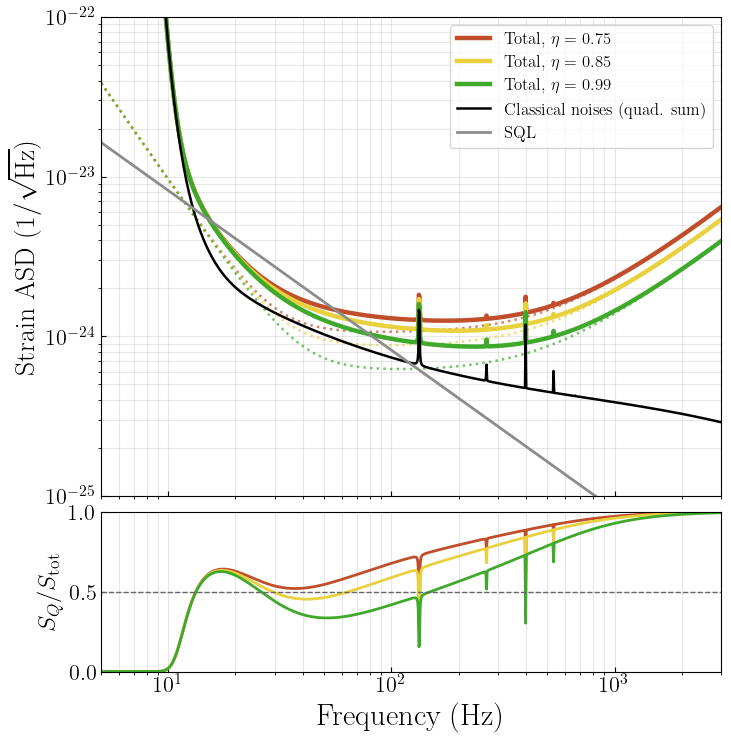

In [7]:
# --- how much of the QE gain survives the classical floor ---
_trapz = np.trapezoid if hasattr(np, 'trapezoid') else np.trapz   # numpy 2 renamed trapz

def classical_sum(t, qkey='Quantum'):
    return np.sqrt(sum(t[k].asd**2 for k in t.keys() if k != qkey))

def range_proxy(asd, fmin=8, fmax=1000):
    """sensemon-style figure of merit, for RATIOS only (constants dropped)."""
    k = (freq >= fmin) & (freq <= fmax)
    return np.sqrt(_trapz(freq[k]**(-7/3) / asd[k]**2, freq[k]))

fig, (ax, axf) = plt.subplots(2, 1, figsize=(8, 8.5), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1], hspace=0.05))
ref = None
for qe, c in QE_style:
    _, t = get_trace('Freq Dependent', 10, 0, qe=qe)
    ax.loglog(freq, t['Quantum'].asd, color=c, ls=':', lw=1.8, alpha=0.7)
    ax.loglog(freq, t.asd, color=c, ls='-', lw=3.2,
              label=rf'Total, $\eta = {qe:.2f}$')
    axf.semilogx(freq, t['Quantum'].asd**2 / t.asd**2, color=c, lw=2)
    if ref is None:
        ref = (range_proxy(t.asd), range_proxy(t['Quantum'].asd))
    print(f'eta={qe:.2f}: range proxy  total x{range_proxy(t.asd)/ref[0]:.3f}'
          f'   quantum-only x{range_proxy(t["Quantum"].asd)/ref[1]:.3f}')

ax.loglog(freq, classical_sum(t), color='k', lw=1.8,
          label=r'Classical noises (quad. sum)')   # QE-independent
ax.loglog(freq, h_SQL, color='0.55', lw=2.0, label=r'SQL')
ax.set_ylabel(r'Strain ASD $(1/\sqrt{\mathrm{Hz}})$', fontsize=20)
ax.set_ylim(1e-25, 1e-22); ax.grid(True, which='both', alpha=0.3)
ax.legend(loc='upper right', fontsize=12, frameon=True)
ax.tick_params(axis='both', which='major', labelsize=16, direction='in')

axf.set_ylabel(r'$S_Q/S_{\mathrm{tot}}$', fontsize=18)
axf.set_xlabel(r'Frequency (Hz)', fontsize=22)
axf.set_ylim(0, 1); axf.set_xlim(5, 3000); axf.grid(True, which='both', alpha=0.3)
axf.axhline(0.5, color='0.4', ls='--', lw=1)
axf.tick_params(axis='both', which='major', labelsize=16, direction='in')
fig.savefig(os.path.join(fig_dir, "QE_impact_on_total_Voyager.png"),
            dpi=300, bbox_inches='tight', facecolor='white')
plt.show()

combine with code above and verify it.
(attempt at using inpiral range)



eta=0.75:  total  708.1 Mpc (x1.000)   quantum-only  930.3 Mpc (x1.000)
eta=0.85:  total  765.7 Mpc (x1.081)   quantum-only 1055.5 Mpc (x1.135)
eta=0.99:  total  859.3 Mpc (x1.214)   quantum-only 1323.6 Mpc (x1.423)


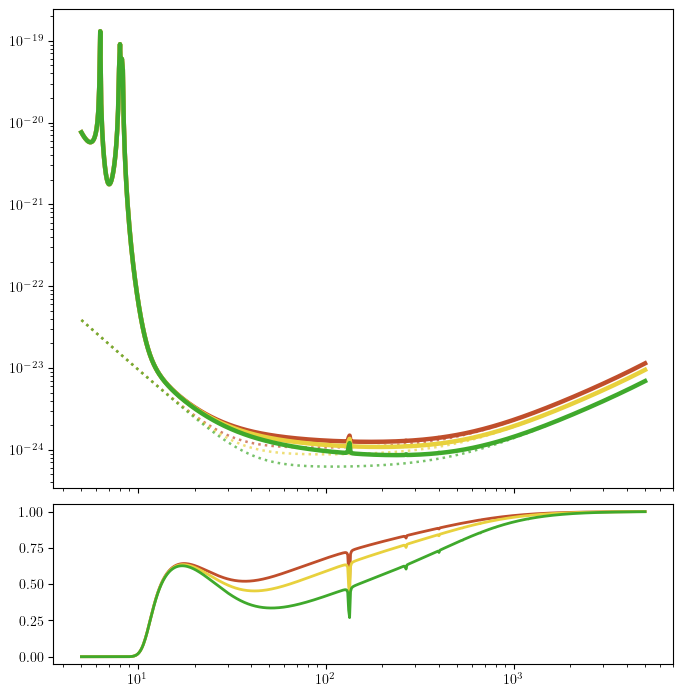

In [31]:
import inspiral_range

def classical_sum(t, qkey='Quantum'):
    return np.sqrt(sum(t[k].asd**2 for k in t.keys() if k != qkey))

def sensemon(psd, m1=1.4, m2=1.4):
    """BNS sensemon range in Mpc. Pass a PSD, not an ASD."""
    return inspiral_range.all_ranges(freq, psd, m1=m1, m2=m2)[0]['sensemon_range'][0]

fig, (ax, axf) = plt.subplots(2, 1, figsize=(8, 8.5), sharex=True,
                              gridspec_kw=dict(height_ratios=[3, 1], hspace=0.05))
ref = None
for qe, c in QE_style:
    _, t = get_trace('Freq Dependent', 10, 0, qe=qe)
    ax.loglog(freq, t['Quantum'].asd, color=c, ls=':', lw=1.8, alpha=0.7)
    ax.loglog(freq, t.asd, color=c, ls='-', lw=3.2, label=rf'Total, $\eta = {qe:.2f}$')
    axf.semilogx(freq, t['Quantum'].asd**2/t.asd**2, color=c, lw=2)

    r_tot = sensemon(t.psd)                                  # what the detector really gains
    r_qo  = sensemon(t['Quantum'].psd)                        # quantum noise alone
    if ref is None:
        ref = (r_tot, r_qo)
    print(f'eta={qe:.2f}:  total {r_tot:6.1f} Mpc (x{r_tot/ref[0]:.3f})   '
          f'quantum-only {r_qo:6.1f} Mpc (x{r_qo/ref[1]:.3f})')
# ... rest of the plotting unchanged